# Curso: Redes Neurais para Processamento de Linguagem Natural

Prof. [Denilson Alves Pereira](https://sites.google.com/ufla.br/denilsonpereira) <br>
Departamento de Ciência da Computação (DCC) <br>
Instituto de Ciências Exatas e Tecnológicas (ICET) <br> 
Universidade Federal de Lavras (UFLA)

**Aluno:** Marcos Carvalho Ferreira - **Matrícula:** 2026160060

# Atividade Prática 01

**Instruções:**
1. Siga os passos indicados em cada célula abaixo para completar a atividade.
2. Você deve inserir código somente entre as linhas marcadas com **INICIE O CÓDIGO AQUI** e **TERMINE O CÓDIGO AQUI**. Há uma indicação de quantas linhas de código são necessárias.
3. Em alguns pontos, confira o resultado esperado conforme marcado com **SAÍDA ESPERADA**.

**Tempo estimado para execução**: 2,0 horas

Versão: Maio, 2024

## O Problema a ser Resolvido

O objetivo da atividade é elaborar modelos baseados em Redes Neurais Recorrentes para a tarefa de classificação de textos. Classificação de texto é uma tarefa de PLN que atribui um rótulo (ou classe) a um texto. <br>

Nesta atividade, você vai usar um dataset de mensagens de texto, e o seu modelo vai predizer aquelas que são *spam* e as que não são *spam* (*ham*). Este é um problema de classificação binária. <br>

Você vai praticar as seguintes habilidades:
- Preprocessar os dados
- Usar as bibliotecas de Redes Neurais Recorrentes
- Configurar arquiteturas de redes neurais usando camadas LSTM e GRU
- Treinar modelos para classificação das mensagens
- Avaliar os modelos treinados

Referências: <br>
Código adaptado de:<br>
https://nzlul.medium.com/the-classification-of-text-messages-using-lstm-bi-lstm-and-gru-f79b207f90ad<br>
Documentação da API Keras para Camadas Recorrentes:<br>
https://keras.io/api/layers/recurrent_layers/<br>
https://www.tensorflow.org/guide/keras/working_with_rnns<br>

## Pacotes

In [268]:
# Load, explore and plot data
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator
%matplotlib inline
# Train test split
from sklearn.model_selection import train_test_split
# Text pre-processing
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping
# Modeling
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Embedding, Dropout, GlobalAveragePooling1D, Flatten, SpatialDropout1D, Bidirectional

## Pré-Processamento dos Dados

### Dataset

Base de dados de mensagens SMS de celulares, publicamente disponível na UCL datasets (https://archive.ics.uci.edu/dataset/228/sms+spam+collection). Pode também ser baixada de https://raw.githubusercontent.com/kenneth-lee-ch/SMS-Spam-Classification/master/spam.csv<br>
O dataset contém 5.574 mensagens rotuladas como *spam* ou não *spam* (*ham*).

A biblioteca Pandas foi usada para ler e manipular o dataset.

In [269]:
# read the dataset
df = pd.read_csv('./datasets/spam.csv', encoding='ISO-8859-1')
# rename the columns
df = df[['v1','v2']]
df.rename(columns={'v1':'label', 'v2':'message'}, inplace=True)
# show the first instances
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


### Estatísticas sobre os Dados

Exibe um sumário das estatísticas para melhor entender os dados

In [270]:
df.describe()

,label,message
count,5572,5572
unique,2,5169
top,ham,"Sorry, I'll call later"
freq,4825,30


In [271]:
df.groupby('label').describe().T

label                              ham  \
message count                     4825   
        unique                    4516   
        top     Sorry, I'll call later   
        freq                        30   

label                                                        spam  
message count                                                 747  
        unique                                                653  
        top     Please call our customer service representativ...  
        freq                                                    4

### Nuvem de Palavras

Visualiza as palavras mais frequentes em cada classe usando uma nuvem de palavras

In [272]:
ham_msg  = df.loc[df['label'] == 'ham']
spam_msg = df.loc[df['label'] == 'spam']

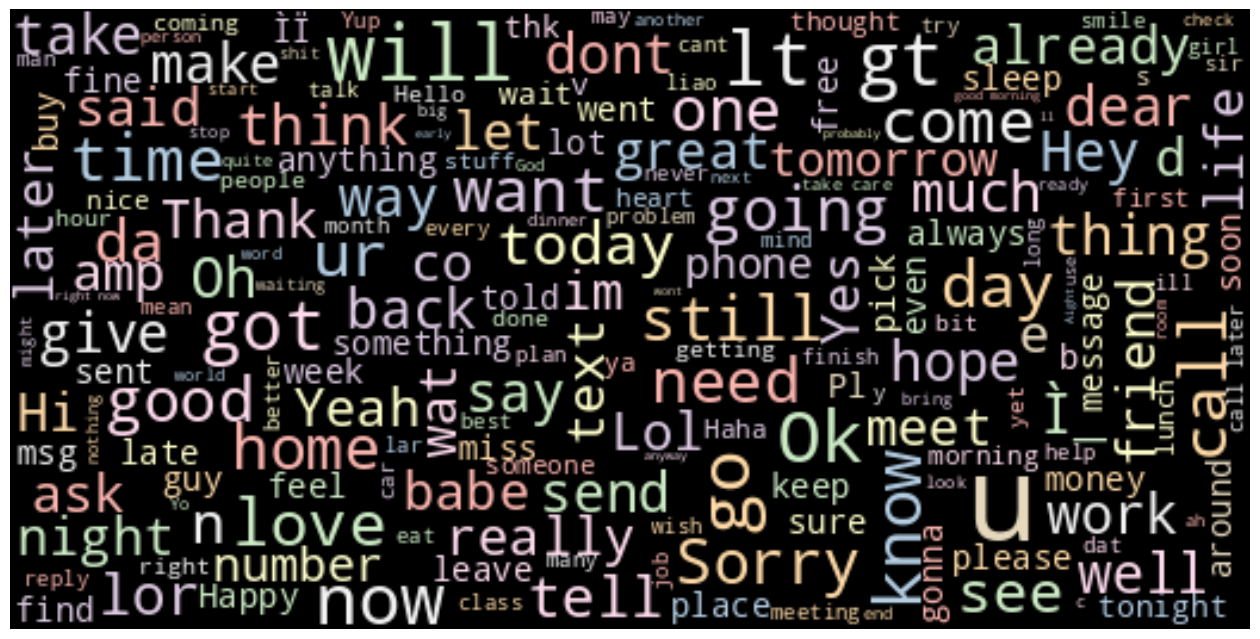

In [273]:
# Nuvem de palavras da classe 'ham'
ham_msg_text = ' '.join(ham_msg['message'])
ham_msg_cloud = WordCloud(width =520, height =260, stopwords = STOPWORDS, max_font_size = 50, background_color = "black", colormap = 'Pastel1').generate(ham_msg_text)
plt.figure(figsize=(16,10))
plt.imshow(ham_msg_cloud, interpolation = 'bilinear')
plt.axis('off') # turn off axis
plt.show()

Palavras mais frequentes da classe 'ham', de acordo com a nuvem de palavras: now, will, ok, today, Sorry etc.

Adicione abaixo um trecho de código para gerar a nuvem de palavras para os textos da classe 'spam'.<br>
Depois, verifique as palavras mais frequentes da classe.

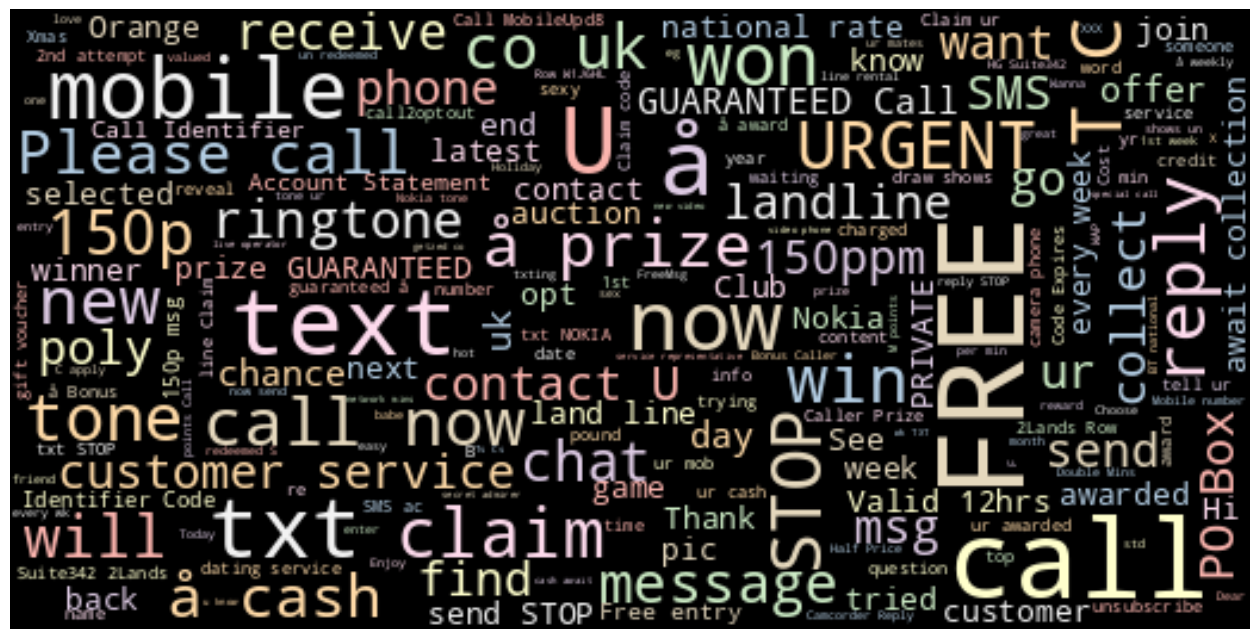

In [274]:
# Nuvem de palavras da classe 'spam'
### INICIE O CÓDIGO AQUI ### (6 ou mais linhas de código)
spam_msg_text = ' '.join(spam_msg['message'])
spam_msg_cloud = WordCloud(width =520, height =260, stopwords = STOPWORDS, max_font_size = 50, background_color = "black", colormap = 'Pastel1').generate(spam_msg_text)
plt.figure(figsize=(16,10))
plt.imshow(spam_msg_cloud, interpolation = 'bilinear')
plt.axis('off') # turn off axis
plt.show()
### TERMINE O CÓDIGO AQUI ###

Palavras mais frequentes da classe 'spam', de acordo com a nuvem de palavras: FREE, call, URGENT, mobile, etc

### Balanceamento dos Dados

Como veremos abaixo, o dataset está muito desbalanceado. Existem muito mais mensagens na classe 'ham' do que na classe 'spam'.<br>
O treinamento de modelos de aprendizagem de máquina a partir de datasets muito desbalanceados pode gerar um viés, levando o modelo a predizer a classe mais frequente.<br>

Existem algumas abordagens para tratar o problema de dados desbalanceados, dentre elas: escolher métricas de avaliação mais apropriadas, resampling (oversampling and undersampling), Synthetic Minority Oversampling Technique (SMOTE), BalancedBaggingClassifier, Threshold moving.<br>

Neste notebook, nós usaremos o método undersampling (subamostragem) para manusear os dados desbalanceados. A técnica consiste em subamostrar a classe majoritária de forma aleatória e uniforme, escolhendo, aproximadamente, o mesmo número de instâncias da classe minoritária. Isso pode potenciamente conduzir a perda de informação, mas se os exemplos da classe majoritária estiverem próximos uns aos outros, esse método pode levar a bons resultados.

Text(0.5, 1.0, 'The distribution of ham and spam messages')

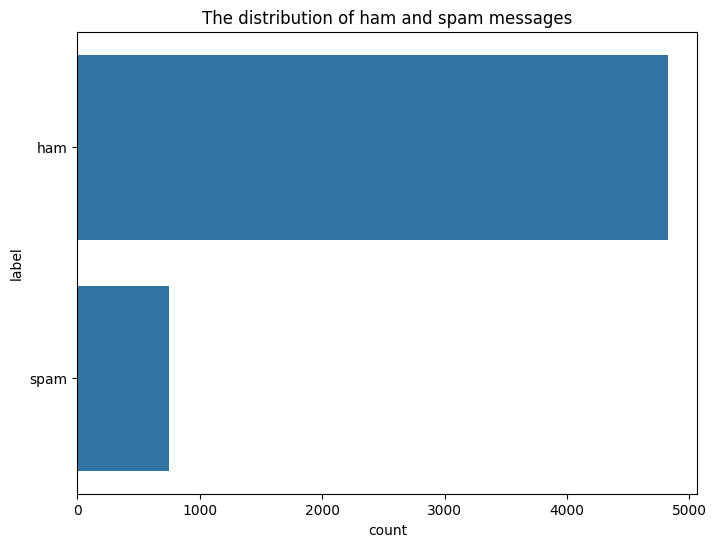

In [275]:
# Distribuição das mensagens em 'ham' e 'spam'
plt.figure(figsize=(8,6))
sns.countplot(df.label)
plt.title('The distribution of ham and spam messages')

In [276]:
# downsample the ham msg
ham_msg_df = ham_msg.sample(n = len(spam_msg), random_state = 44)

In [277]:
msg_df = pd.concat([ham_msg_df, spam_msg])
msg_df.head()

,label,message
3234,ham,"Yes, princess. Toledo."
3804,ham,Dude while were makin those weirdy brownies my...
2701,ham,"Hiya, sorry didn't hav signal. I haven't seen ..."
2822,ham,Then u ask darren go n pick u lor... But i oso...
5161,ham,Lol no. I just need to cash in my nitros. Hurr...


In [278]:
msg_df.tail()

,label,message
5537,spam,Want explicit SEX in 30 secs? Ring 02073162414...
5540,spam,ASKED 3MOBILE IF 0870 CHATLINES INCLU IN FREE ...
5547,spam,Had your contract mobile 11 Mnths? Latest Moto...
5566,spam,REMINDER FROM O2: To get 2.50 pounds free call...
5567,spam,This is the 2nd time we have tried 2 contact u...


Text(0.5, 1.0, 'The distribution of ham and spam messages')

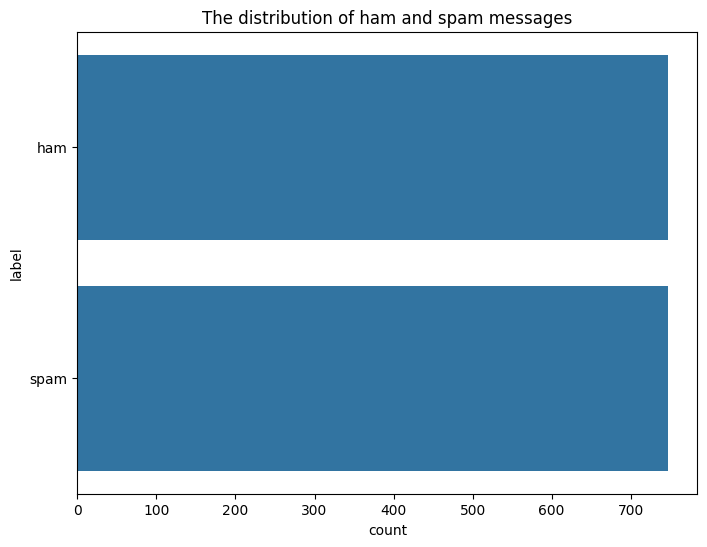

In [279]:
# Nova distribuição
plt.figure(figsize=(8,6))
sns.countplot(msg_df.label)
plt.title('The distribution of ham and spam messages')

### Pré-processamento do Texto

Cria duas colunas no *dataframe*: uma para armazenar o comprimento de cada mensagem de texto e outra para armazenar o rótulo da classe convertido para um valor numérico (0: ham, 1: spam).

In [280]:
# Get length column for each text
msg_df['text_length'] = msg_df['message'].apply(len)
# Get the converted numeric label of the data
msg_df['msg_type'] = msg_df['label'].map({'ham':0, 'spam':1})
msg_df.head()

,label,message,text_length,msg_type
3234,ham,"Yes, princess. Toledo.",22,0
3804,ham,Dude while were makin those weirdy brownies my...,88,0
2701,ham,"Hiya, sorry didn't hav signal. I haven't seen ...",169,0
2822,ham,Then u ask darren go n pick u lor... But i oso...,74,0
5161,ham,Lol no. I just need to cash in my nitros. Hurr...,75,0


In [281]:
msg_df.tail()

,label,message,text_length,msg_type
5537,spam,Want explicit SEX in 30 secs? Ring 02073162414...,90,1
5540,spam,ASKED 3MOBILE IF 0870 CHATLINES INCLU IN FREE ...,160,1
5547,spam,Had your contract mobile 11 Mnths? Latest Moto...,160,1
5566,spam,REMINDER FROM O2: To get 2.50 pounds free call...,147,1
5567,spam,This is the 2nd time we have tried 2 contact u...,161,1


### Divisão dos Dados em Treino e Teste

Os dados são divididos, aletatoriamente, em 80% para treino e 20% para teste.

In [282]:
X_train, X_test, y_train, y_test = train_test_split(msg_df['message'], msg_df['msg_type'], test_size=0.2, random_state=434)

In [283]:
X_train.tail()

1364    Hey i will be really pretty late... You want t...
1121    Do you want 750 anytime any network mins 150 t...
4458    Welcome to UK-mobile-date this msg is FREE giv...
2900    Ur cash-balance is currently 500 pounds - to m...
5269    If you don't, your prize will go to another cu...
Name: message, dtype: object

In [284]:
y_train.tail()

1364    0
1121    1
4458    1
2900    1
5269    1
Name: msg_type, dtype: int64

### Tokenização

Os textos das mensagens precisam ser convertidos para uma representação numérica, para que o modelo possa entendê-los.

A API Tokenizer do TensorFlow divide as sentenças em palavras e as codifica em números inteiros.

O Tokenizer executará os seguintes passos de pré-processamento: tokeniza a nível de palavras, remove os termos de pontuação, converte todas as palavras para minúsculas, converte todas as palavras para números inteiros. Os seguintes parâmetros foram definidos:
- num_words: número de palavras únicas (vocabulário)
- oov_token: token usado para substituir palavras que não estiverem no vocabulário

In [285]:
# Defining pre-processing parameters
max_len = 50 
trunc_type = 'post'
padding_type = 'post'
oov_tok = '<OOV>' # out of vocabulary token
vocab_size = 500

In [286]:
tokenizer = Tokenizer(num_words = vocab_size, 
                      char_level = False,
                      oov_token = oov_tok)
tokenizer.fit_on_texts(X_train)

In [287]:
# Get the word_index
word_index = tokenizer.word_index
total_words = len(word_index)
total_words

4054

Em seguida, cada sentença é representada por uma sequência de números usando o método texts_to_sequences do objeto Tokenizer.

Depois, cada setença é completada com o token de 'pad' ou truncada para que todas tenham o mesmo comprimento.

Os parâmetros são:
- maxlen: tamanho máximo de todas as sequências. O valor *default* é o comprimento da sentença mais longa.
- padding: 'pre' ou 'post' (*default*). Completa com tokens 'pad' antes ('pre') ou depois ('post') de cada sequencia.
- truncating: 'pre' ou 'post' (*default*). Se o tamanho de uma sentença for maior do que o valor de 'maxlen', ela será truncada para 'maxlen'. A opção 'pre' trunca no início e 'post' trunca no final da sequência.

In [288]:
# Dados de treino
training_sequences = tokenizer.texts_to_sequences(X_train)
training_padded = pad_sequences(training_sequences,
                                maxlen = max_len,
                                padding = padding_type,
                                truncating = trunc_type)

In [289]:
# Dados de teste
testing_sequences = tokenizer.texts_to_sequences(X_test)
testing_padded = pad_sequences(testing_sequences,
                               maxlen = max_len,
                               padding = padding_type,
                               truncating = trunc_type)

In [290]:
# Formato dos tensores de treino e teste
print('Shape of training tensor: ', training_padded.shape)
print('Shape of testing tensor: ', testing_padded.shape)

Shape of training tensor:  (1195, 50)
Shape of testing tensor:  (299, 50)


## Configuração do Modelo de Classificação

Define a arquitetura do modelo de classificação. O modelo usa uma Rede Neural Recorrente do tipo LSTM (Long Short Term Memory) Bidirecional.

O modelo sequencial Keras permite a adição de camadas em uma sequência. Você deve adicionar as seguintes camadas em sequência:
- Camada de Embedding, que mapeia cada palavra para um vetor N-dimensional de número reais. O 'embedding_dim' é o tamanho do vetor, nesse caso, 16. Como a camada de embedding é a primeira camada oculta do modelo, a camada de entrada deve ser definida por input_length = max_len.
- Camada LSTM bidirecional, com 128 unidades.
- Camada de Dropout com uma fração de drop = 0.2
- Camada Densa (camada de classificação binária) com uma unidade e função de ativação sigmoid.

In [291]:
embedding_dim = 16  # tamanho do embedding (vetor) de palavras
n_lstm = 128        # número de unidades (dimensionalidade da saída)
drop_lstm = 0.2     # fração das unidades para drop

In [292]:
model = Sequential()
model.add(Embedding(vocab_size,
                    embedding_dim,
                    input_length = max_len))
### INICIE O CÓDIGO AQUI ### (3 linhas de código)
model.add(Bidirectional(LSTM(n_lstm)))
model.add(Dropout(drop_lstm))
model.add(Dense(1, activation='sigmoid'))
### TERMINE O CÓDIGO AQUI ###

Exibe um sumário do modelo

In [293]:
model.summary()

Model: "sequential_13"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_13 (Embedding)    (None, 50, 16)            8000      
                                                                 
 bidirectional_23 (Bidirect  (None, 256)               148480    
 ional)                                                          
                                                                 
 dropout_13 (Dropout)        (None, 256)               0         
                                                                 
 dense_13 (Dense)            (None, 1)                 257       
                                                                 
Total params: 156737 (612.25 KB)
Trainable params: 156737 (612.25 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


**SAÍDA ESPERADA:** <br>

Compila o modelo Keras para configurar o processo de treinamento

In [294]:
model.compile(loss = 'binary_crossentropy',
              optimizer = 'adam',
              metrics=['accuracy'])

## Treinamento do Modelo

Treina o modelo de classificação usando o método 'fit'.

EarlyStopping (monitor='val_loss', patience=2) define que o método vai monitorar a perda nos dados de validação, e se a perda não for melhorada após 2 épocas, então o modelo de treinamento é finalizado. Essa técnica ajuda a evitar problemas de *overfitting*.

In [295]:
num_epochs = 30
early_stop = EarlyStopping(monitor = 'val_loss',
                           patience = 2)
history = model.fit(training_padded,
                    y_train,
                    epochs = num_epochs,
                    validation_data = (testing_padded, y_test),
                    callbacks = [early_stop],
                    verbose = 2)

Epoch 1/30
38/38 - 7s - loss: 0.5800 - accuracy: 0.7121 - val_loss: 0.2745 - val_accuracy: 0.8930 - 7s/epoch - 182ms/step
Epoch 2/30
38/38 - 2s - loss: 0.1930 - accuracy: 0.9280 - val_loss: 0.1332 - val_accuracy: 0.9532 - 2s/epoch - 60ms/step
Epoch 3/30
38/38 - 3s - loss: 0.1527 - accuracy: 0.9506 - val_loss: 0.1812 - val_accuracy: 0.9398 - 3s/epoch - 69ms/step
Epoch 4/30
38/38 - 2s - loss: 0.1251 - accuracy: 0.9607 - val_loss: 0.0934 - val_accuracy: 0.9666 - 2s/epoch - 56ms/step
Epoch 5/30
38/38 - 2s - loss: 0.0916 - accuracy: 0.9749 - val_loss: 0.1031 - val_accuracy: 0.9732 - 2s/epoch - 57ms/step
Epoch 6/30
38/38 - 2s - loss: 0.1006 - accuracy: 0.9649 - val_loss: 0.0996 - val_accuracy: 0.9699 - 2s/epoch - 59ms/step


Plota gráficos de acurácia e perda

In [296]:
def plot_graphs(history, metric):
  plt.plot(history.history[metric])
  plt.plot(history.history['val_'+metric], '')
  plt.xlabel("Epochs")
  plt.ylabel(metric)
  plt.legend([metric, 'val_'+metric])

(0.0, 0.6044289451092482)

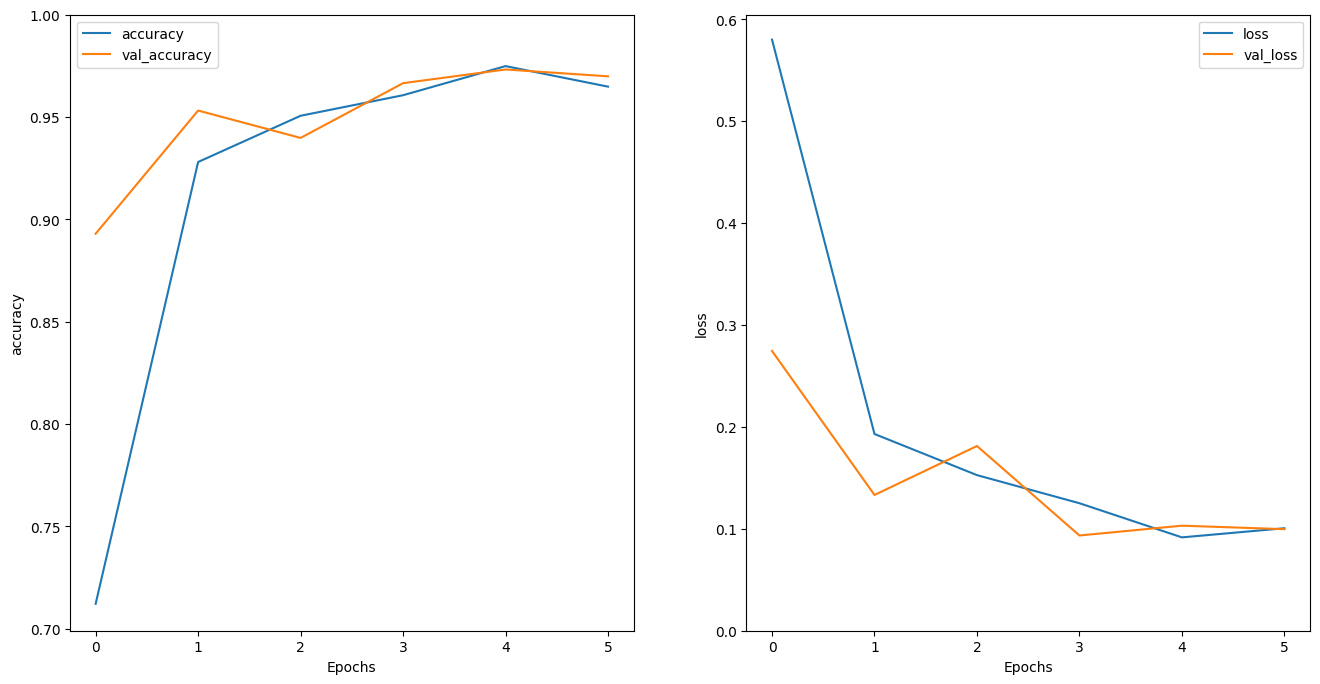

In [297]:
plt.figure(figsize=(16, 8))
plt.subplot(1, 2, 1)
plot_graphs(history, 'accuracy')
plt.ylim(None, 1)
plt.subplot(1, 2, 2)
plot_graphs(history, 'loss')
plt.ylim(0, None)

## Avaliação do Modelo

Avalia o desempenho do modelo no conjunto de teste.

In [298]:
loss_lstm1, acc_lstm1 = model.evaluate(testing_padded, y_test)
print(f"LSTM model loss: {loss_lstm1} " )
print(f"LSTM model accuracy: {acc_lstm1*100:0.2f}%" )

10/10 [==============================] - 0s 17ms/step - loss: 0.0996 - accuracy: 0.9699
LSTM model loss: 0.0996479019522667 
LSTM model accuracy: 96.99%


## Predição

Prediz a saída de novas mensagens

In [299]:
predict_msg = ["Have friends and colleagues who could benefit from these weekly updates? Send them to this link to subscribe",
               "Call me"]

In [300]:
def predict_spam(predict_msg):
  new_seq = tokenizer.texts_to_sequences(predict_msg)
  padded = pad_sequences(new_seq,
                         maxlen = max_len,
                         padding = padding_type,
                         truncating = trunc_type)
  return(model.predict(padded))

In [301]:
# 'ham' se predict < 0.5 senão 'spam'
predict_spam(predict_msg)

1/1 [==============================] - 1s 518ms/step


array([[0.9430402 ],
       [0.01490783]], dtype=float32)

## Desafio 1

Modifique a configuração do modelo de classificação de forma a usar três camadas de LSTM Bidirecional, em vez de apenas uma, como foi feito do código acima.

Você vai precisar replicar todas as células do notebook, desde a Configuração do Modelo de Classificação, fazendo as devidas adaptações para a nova configuração.

A saída esperada para o model.sumary() da nova arquitetura é:

Adicione abaixo a nova sequência de código.

In [302]:
### INICIE O CÓDIGO AQUI ### (várias linhas de código / várias células)

#### Configuração do Modelo de Classificação

In [303]:
model = Sequential()
model.add(Embedding(vocab_size,
                    embedding_dim,
                    input_length = max_len))
model.add(Bidirectional(LSTM(128, return_sequences=True)))
model.add(Bidirectional(LSTM(128, return_sequences=True)))
model.add(Bidirectional(LSTM(128)))
model.add(Dropout(0.2))
model.add(Dense(1, activation='sigmoid'))

model.summary()

Model: "sequential_14"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_14 (Embedding)    (None, 50, 16)            8000      
                                                                 
 bidirectional_24 (Bidirect  (None, 50, 256)           148480    
 ional)                                                          
                                                                 
 bidirectional_25 (Bidirect  (None, 50, 256)           394240    
 ional)                                                          
                                                                 
 bidirectional_26 (Bidirect  (None, 256)               394240    
 ional)                                                          
                                                                 
 dropout_14 (Dropout)        (None, 256)               0         
                                                     

In [304]:
model.compile(loss = 'binary_crossentropy',
                   optimizer = 'adam',
                   metrics=['accuracy'])

#### Treinamento do Modelo

In [305]:
history = model.fit(training_padded,
                    y_train,
                    epochs = num_epochs,
                    validation_data = (testing_padded, y_test),
                    callbacks = [early_stop],
                    verbose = 2)

Epoch 1/30
38/38 - 22s - loss: 0.4550 - accuracy: 0.7841 - val_loss: 0.2825 - val_accuracy: 0.8863 - 22s/epoch - 578ms/step
Epoch 2/30
38/38 - 11s - loss: 0.1683 - accuracy: 0.9389 - val_loss: 0.1224 - val_accuracy: 0.9632 - 11s/epoch - 290ms/step
Epoch 3/30
38/38 - 11s - loss: 0.1104 - accuracy: 0.9657 - val_loss: 0.0661 - val_accuracy: 0.9766 - 11s/epoch - 284ms/step
Epoch 4/30
38/38 - 11s - loss: 0.0962 - accuracy: 0.9682 - val_loss: 0.0866 - val_accuracy: 0.9799 - 11s/epoch - 294ms/step
Epoch 5/30
38/38 - 11s - loss: 0.0805 - accuracy: 0.9774 - val_loss: 0.0818 - val_accuracy: 0.9732 - 11s/epoch - 286ms/step


(0.0, 0.4743949308991432)

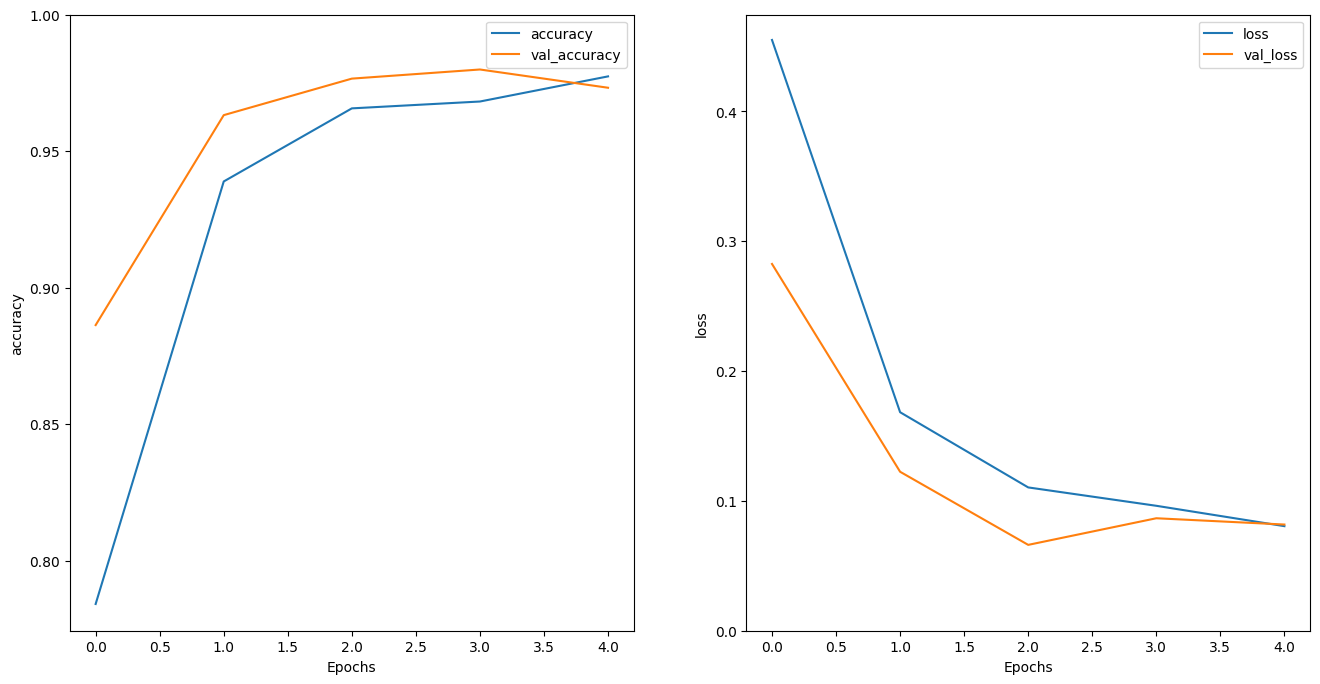

In [306]:
plt.figure(figsize=(16, 8))
plt.subplot(1, 2, 1)
plot_graphs(history, 'accuracy')
plt.ylim(None, 1)
plt.subplot(1, 2, 2)
plot_graphs(history, 'loss')
plt.ylim(0, None)

#### Avaliação do Modelo

In [307]:
loss_lstm3, acc_lstm3 = model.evaluate(testing_padded, y_test)
print(f"LSTM model loss: {loss_lstm3} " )
print(f"LSTM model accuracy: {acc_lstm3*100:0.2f}%" )

10/10 [==============================] - 1s 64ms/step - loss: 0.0818 - accuracy: 0.9732
LSTM model loss: 0.08177600055932999 
LSTM model accuracy: 97.32%


#### Predição

In [308]:
# 'ham' se predict < 0.5 senão 'spam'
predict_spam(predict_msg)

1/1 [==============================] - 2s 2s/step


array([[0.9958538],
       [0.0113772]], dtype=float32)

In [309]:
### TERMINE O CÓDIGO AQUI ###

## Desafio 2

Modifique a configuração do modelo de classificação de forma a usar uma Gated Recurrent Unit (GRU) Bidirecional, em vez de uma LSTM.

Você vai precisar replicar todas as células do notebook, desde a Configuração do Modelo de Classificação, fazendo as devidas adaptações para a nova configuração.

A saída esperada para o model.sumary() da nova arquitetura é:

Adicione abaixo a nova sequência de código.

In [310]:
### INICIE O CÓDIGO AQUI ### (várias linhas de código / várias células)

#### Configuração do Modelo de Classificação

In [311]:
model = Sequential()
model.add(Embedding(vocab_size,
                    embedding_dim,
                    input_length = max_len))
model.add(Bidirectional(GRU(128)))
model.add(Dropout(0.2))
model.add(Dense(1, activation='sigmoid'))

model.summary()

Model: "sequential_15"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_15 (Embedding)    (None, 50, 16)            8000      
                                                                 
 bidirectional_27 (Bidirect  (None, 256)               112128    
 ional)                                                          
                                                                 
 dropout_15 (Dropout)        (None, 256)               0         
                                                                 
 dense_15 (Dense)            (None, 1)                 257       
                                                                 
Total params: 120385 (470.25 KB)
Trainable params: 120385 (470.25 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [312]:
model.compile(loss = 'binary_crossentropy',
                   optimizer = 'adam',
                   metrics=['accuracy'])

#### Treinamento do Modelo

In [313]:
history = model.fit(training_padded,
                    y_train,
                    epochs = num_epochs,
                    validation_data = (testing_padded, y_test),
                    callbacks = [early_stop],
                    verbose = 2)

Epoch 1/30
38/38 - 5s - loss: 0.6629 - accuracy: 0.6393 - val_loss: 0.4879 - val_accuracy: 0.8696 - 5s/epoch - 131ms/step
Epoch 2/30
38/38 - 2s - loss: 0.4358 - accuracy: 0.7858 - val_loss: 0.2727 - val_accuracy: 0.9298 - 2s/epoch - 43ms/step
Epoch 3/30
38/38 - 2s - loss: 0.1839 - accuracy: 0.9515 - val_loss: 0.1317 - val_accuracy: 0.9532 - 2s/epoch - 42ms/step
Epoch 4/30
38/38 - 2s - loss: 0.1065 - accuracy: 0.9632 - val_loss: 0.1233 - val_accuracy: 0.9599 - 2s/epoch - 42ms/step
Epoch 5/30
38/38 - 2s - loss: 0.0938 - accuracy: 0.9724 - val_loss: 0.0945 - val_accuracy: 0.9666 - 2s/epoch - 41ms/step
Epoch 6/30
38/38 - 2s - loss: 0.0776 - accuracy: 0.9741 - val_loss: 0.1422 - val_accuracy: 0.9532 - 2s/epoch - 43ms/step
Epoch 7/30
38/38 - 2s - loss: 0.0632 - accuracy: 0.9808 - val_loss: 0.0768 - val_accuracy: 0.9666 - 2s/epoch - 42ms/step
Epoch 8/30
38/38 - 2s - loss: 0.0567 - accuracy: 0.9791 - val_loss: 0.0868 - val_accuracy: 0.9732 - 2s/epoch - 42ms/step
Epoch 9/30
38/38 - 2s - loss: 0

(0.0, 0.6941320914775133)

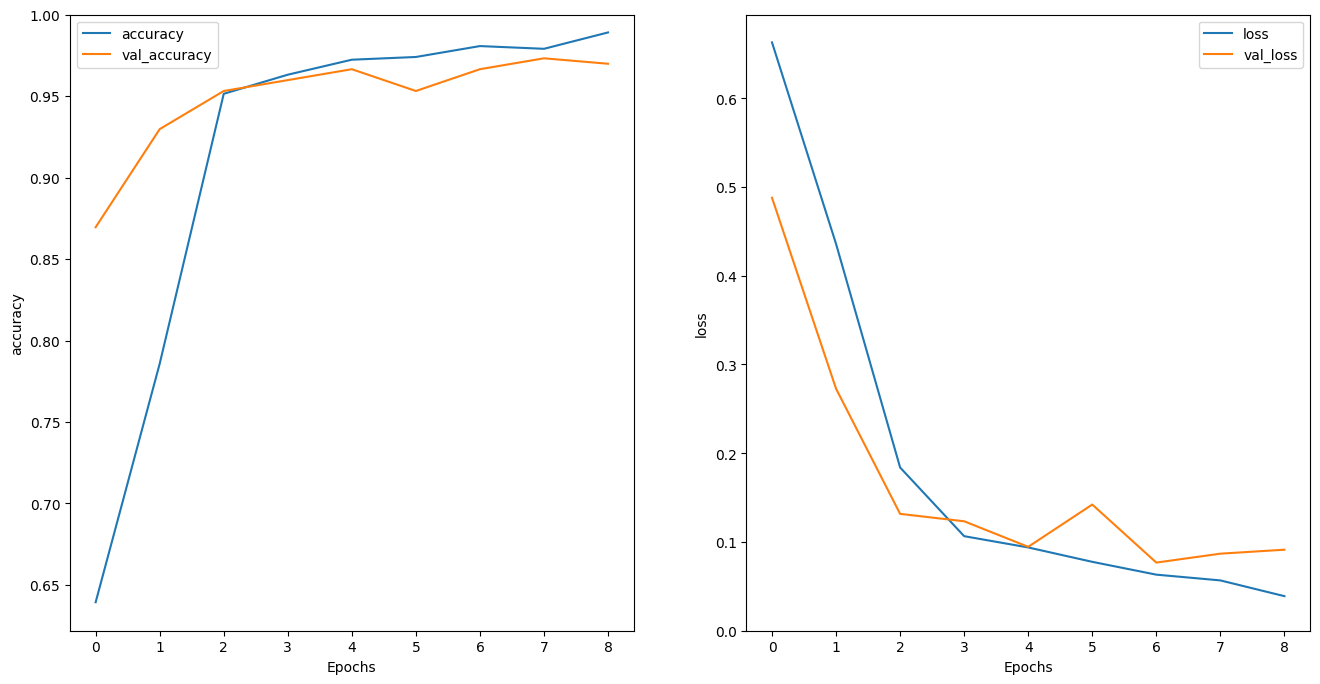

In [314]:
plt.figure(figsize=(16, 8))
plt.subplot(1, 2, 1)
plot_graphs(history, 'accuracy')
plt.ylim(None, 1)
plt.subplot(1, 2, 2)
plot_graphs(history, 'loss')
plt.ylim(0, None)

#### Avaliação do Modelo

In [315]:
loss_gru, acc_gru = model.evaluate(testing_padded, y_test)
print(f"GRU model loss: {loss_gru} " )
print(f"GRU model accuracy: {acc_gru*100:0.2f}%" )

10/10 [==============================] - 0s 9ms/step - loss: 0.0913 - accuracy: 0.9699
GRU model loss: 0.09130857139825821 
GRU model accuracy: 96.99%


#### Predição

In [316]:
# 'ham' se predict < 0.5 senão 'spam'
predict_spam(predict_msg)

1/1 [==============================] - 1s 522ms/step


array([[0.98205495],
       [0.01857385]], dtype=float32)

In [317]:
### TERMINE O CÓDIGO AQUI ###

## Comparação dos Resultados

Adicione abaixo uma tabela com a comparação dos resultados obtidos pelas três configurações efetuadas neste notebook.<br>
Qual configuração obteve o melhor resultados?

In [318]:
### ADICIONE A TABELA DE RESULTADOS AQUI ###
results = pd.DataFrame({
    'Configuração': ['LSTM Bidirecional (1 camada)',
                      'LSTM Bidirecional (3 camadas)',
                      'GRU Bidirecional (1 camada)'],
    'Perda (Loss)': [loss_lstm1, loss_lstm3, loss_gru],
    'Acurácia (%)': [acc_lstm1 * 100, acc_lstm3 * 100, acc_gru * 100]
})

# Ordena da melhor para a pior acurácia
results = results.sort_values(by='Acurácia (%)', ascending=False).reset_index(drop=True)
display(results)

best_config = results.loc[0, 'Configuração']
print(f"\nA configuração com o melhor resultado foi: {best_config}")

,Configuração,Perda (Loss),Acurácia (%)
0,LSTM Bidirecional (3 camadas),0.081776,97.324413
1,LSTM Bidirecional (1 camada),0.099648,96.989965
2,GRU Bidirecional (1 camada),0.091309,96.989965



A configuração com o melhor resultado foi: LSTM Bidirecional (3 camadas)


# Fim

Parabéns! Você efetuou todos os passos para criar modelos baseados em Redes Neurais Recorrentes para a tarefa de classificação de textos.

-------------------------------------------